# **Data Privacy in Fashion E-Commerce: An Exploratory Data Analysis**
### **M504 AI and Applications — Individual Project**
### **Gisma University of Applied Sciences**

# **1. Business Context Client:**
+ **FashionSafe Analytics (Berlin)-** audit of fashion e-commerce concerning the GDPR.
+ **Sample size-** 98,913 user records, 24 variables.
+ **Kaggle Purpose-** EDA to trace exposure of the user data and recommend data minimisation based on GDPR.

# **2. Data Exploration**

The first step before analysis is to know what the dataset structure, quality and characteristics are. The exploration process is recorded in this section.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100


In [2]:
df = pd.read_csv('ds1.csv')
print(f"Users: {df.shape[0]:,}, Columns: {df.shape[1]}")
df.head()

Users: 98,913, Columns: 24


,identifierHash,type,country,language,socialNbFollowers,socialNbFollows,socialProductsLiked,productsListed,productsSold,productsPassRate,...,civilityTitle,hasAnyApp,hasAndroidApp,hasIosApp,hasProfilePicture,daysSinceLastLogin,seniority,seniorityAsMonths,seniorityAsYears,countryCode
0,-7279641312655250028,user,Etats-Unis,en,3,8,0,0,0,0.0,...,mrs,False,False,False,True,709,3205,106.83,8.9,us
1,-1456013578740053406,user,Allemagne,de,3,8,0,0,0,0.0,...,mrs,False,False,False,True,709,3205,106.83,8.9,de
2,9006282053848196165,user,Suède,en,3,8,0,0,0,0.0,...,mr,True,False,True,True,689,3205,106.83,8.9,se
3,-7154634866120535654,user,Turquie,en,3,8,0,0,0,0.0,...,mrs,False,False,False,True,709,3205,106.83,8.9,tr
4,2858299215060733023,user,France,en,3,8,0,0,0,0.0,...,mr,True,False,True,True,709,3205,106.83,8.9,fr


In [18]:
for col in ['gender', 'country', 'language', 'hasAnyApp', 'hasAndroidApp', 'hasIosApp', 'hasProfilePicture']:
  print(df[col].value_counts().head(5));print(f'\n')

gender
F    76121
M    22792
Name: count, dtype: int64


country
France         25135
Etats-Unis     20602
Royaume-Uni    11310
Italie          8015
Allemagne       6567
Name: count, dtype: int64


language
en    51564
fr    26372
it     7766
de     7178
es     6033
Name: count, dtype: int64


hasAnyApp
False    72739
True     26174
Name: count, dtype: int64


hasAndroidApp
False    94094
True      4819
Name: count, dtype: int64


hasIosApp
False    77386
True     21527
Name: count, dtype: int64


hasProfilePicture
True     97018
False     1895
Name: count, dtype: int64




# **2.1 Summary**
* No outliers or redundancy.
* Gender: ~77% female, ~23% male.
* Top countries: France, USA, UK.
* +26 percent are mobile app; 98 percent have profile picture.
* Every user with seniority of 8 or above (cohort snapshot).

# **3. Data Preprocessing**

Even though the dataset does not have any missing values, there is a number of preprocessing steps needed to make this dataset suitable to meaningful analysis.

In [5]:
df_clean = df.copy()

In [6]:
df_clean = df_clean.rename(columns={
    'identifierHash'      : 'user_id',
    'socialNbFollowers'   : 'followers',
    'socialNbFollows'     : 'following',
    'socialProductsLiked' : 'products_liked',
    'productsListed'      : 'products_listed',
    'productsSold'        : 'products_sold',
    'productsPassRate'    : 'pass_rate',
    'productsWished'      : 'products_wishlisted',
    'productsBought'      : 'products_bought',
    'hasAnyApp'           : 'uses_app',
    'hasAndroidApp'       : 'uses_android',
    'hasIosApp'           : 'uses_ios',
    'hasProfilePicture'   : 'has_profile_pic',
    'daysSinceLastLogin'  : 'days_inactive',
    'seniorityAsYears'    : 'account_age_years',
    'countryCode'         : 'country_code'
})
print("Column Renamed:")

Column Renamed:


In [7]:
bool_cols = ['uses_app', 'uses_android', 'uses_ios', 'has_profile_pic']
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print("Boolean columns converted")

Boolean columns converted


In [8]:
df_clean['data_exposure_score'] = (
    df_clean['uses_app'] * 2 +
    df_clean['has_profile_pic'] * 1 +
    (df_clean['products_listed'] > 0).astype(int) +
    (df_clean['products_bought'] > 0).astype(int) +
    (df_clean['products_liked'] > 0).astype(int) +
    (df_clean['products_wishlisted'] > 0).astype(int)
)
print(df_clean['data_exposure_score'].describe())

count    98913.000000
mean         1.837332
std          1.232778
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max          7.000000
Name: data_exposure_score, dtype: float64


In [9]:
def classify_user(row):
    if row['products_bought'] > 0 and row['products_sold'] > 0: return 'Buyer & Seller'
    elif row['products_bought'] > 0: return 'Buyer Only'
    elif row['products_sold'] > 0: return 'Seller Only'
    else: return 'Passive User'
df_clean['user_segment'] = df_clean.apply(classify_user, axis=1)
print(df_clean['user_segment'].value_counts())

user_segment
Passive User      92020
Buyer Only         4857
Seller Only        1474
Buyer & Seller      562
Name: count, dtype: int64


### 3.1 Preprocessing Summary

* Working copy created
* The dropped type, civilityGenderId, and seniorityAsMonths
* Column names renamed to Pythonic
* Booleans → integers
* data_exposure_score engineered
* User segments created
* **Result: 98,913 × 23 columns**


# **4. Exploratory Data Analysis**

In this part, seven business questions pertaining to data privacy, user behaviour, and platform dynamics on a fashion resale platform are considered. The questions are followed by their business rationale, Python code and its analysis.


### Question 1: How is data exposure distributed across users, and who are the most at-risk?

**Rationale:** GDPR art. 5(1) (c) data minimisation - define users with disproportionate data footprints.

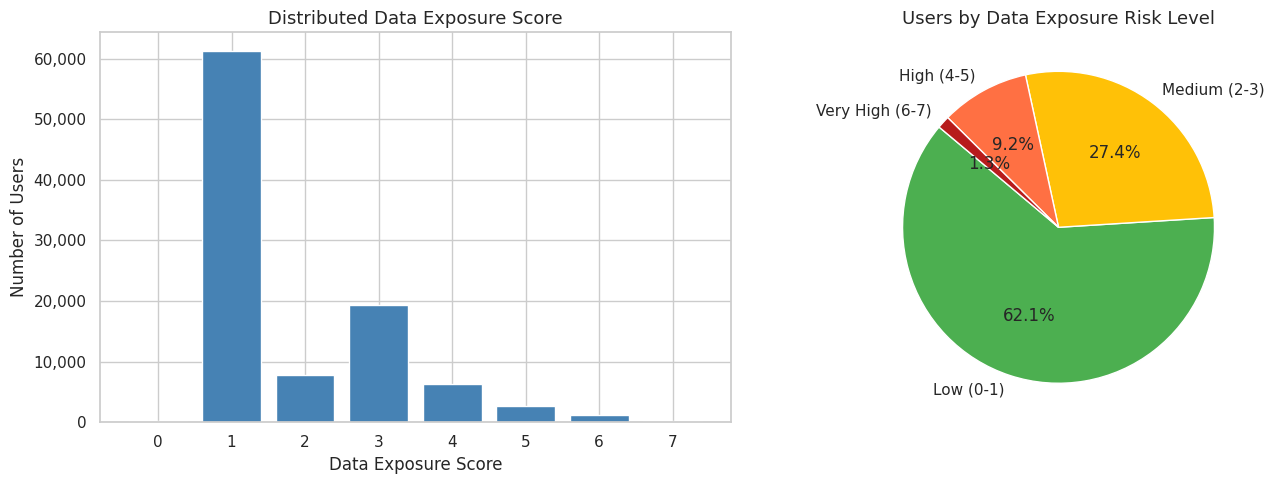

Average data exposure score: 1.84
Users with HIGH or VERY HIGH exposure: 10,373 (10.5%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
score_counts = df_clean['data_exposure_score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distributed Data Exposure Score', fontsize=13)
axes[0].set_xlabel('Data Exposure Score')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
risk_labels = ['Low (0-1)', 'Medium (2-3)', 'High (4-5)', 'Very High (6-7)']
risk_counts = [
    ((df_clean['data_exposure_score'] <= 1)).sum(),
    ((df_clean['data_exposure_score'] >= 2) & (df_clean['data_exposure_score'] <= 3)).sum(),
    ((df_clean['data_exposure_score'] >= 4) & (df_clean['data_exposure_score'] <= 5)).sum(),
    ((df_clean['data_exposure_score'] >= 6)).sum()
]
colors = ['#4CAF50', '#FFC107', '#FF7043', '#B71C1C']
axes[1].pie(risk_counts, labels=risk_labels, colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Users by Data Exposure Risk Level', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Average data exposure score: {df_clean['data_exposure_score'].mean():.2f}")
print(f"Users with HIGH or VERY HIGH exposure: {(df_clean['data_exposure_score'] >= 4).sum():,} ({(df_clean['data_exposure_score'] >= 4).mean()*100:.1f}%)")

**Discovery:** The subjects with a score 4 or higher contain comprehensive, possibly profiling-level data. Platform ought to evaluate data requirements in GDPR Art. 5(1)(c).

### Question 2: Are female users more exposed in terms of data than male users?

Rationale: Disparities of exposure according to gender can be against GDPR proportionality.

Detailed comparison by gender:
        data_exposure_score  products_bought  products_listed  products_liked  \
gender                                                                          
F                     1.811            0.167            0.099           4.908   
M                     1.926            0.187            0.075           2.793   

        has_profile_pic  uses_app  
gender                             
F                 0.981     0.243  
M                 0.980     0.336  


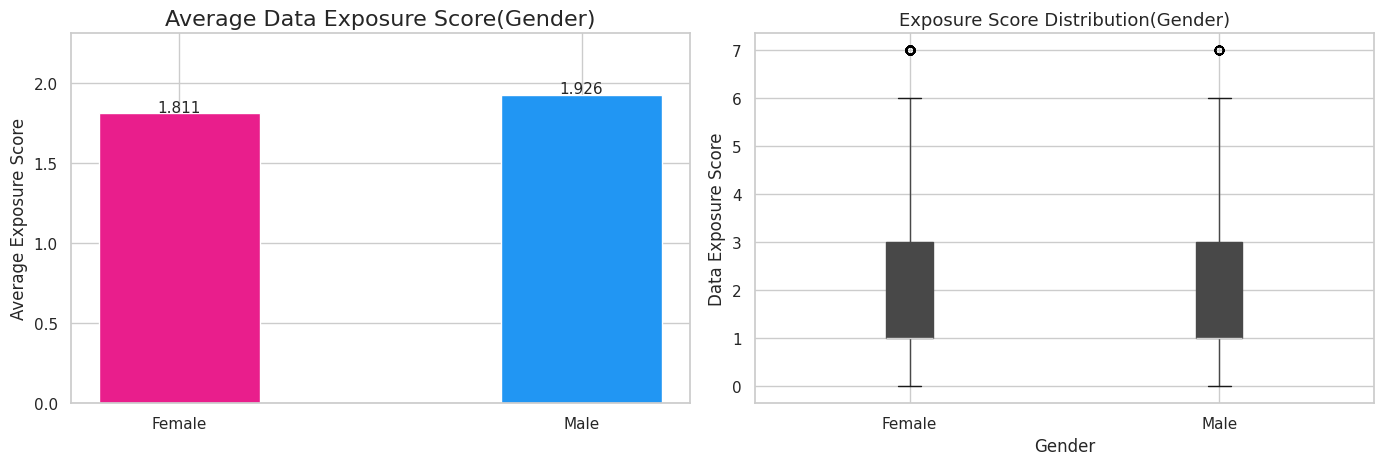

In [11]:
gender_exposure = df_clean.groupby('gender')['data_exposure_score'].mean().reset_index()
gender_exposure.columns = ['Gender', 'Avg Exposure Score']
gender_exposure['Gender'] = gender_exposure['Gender'].map({'F': 'Female', 'M': 'Male'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(gender_exposure['Gender'], gender_exposure['Avg Exposure Score'],
                   color=['#E91E8C', '#2196F3'], edgecolor='white', width=0.4)
for bar, val in zip(bars, gender_exposure['Avg Exposure Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11)
axes[0].set_title('Average Data Exposure Score(Gender)', fontsize=16)
axes[0].set_ylabel('Average Exposure Score')
axes[0].set_ylim(0, gender_exposure['Avg Exposure Score'].max() * 1.2)

gender_plot_data = df_clean[df_clean['gender'].isin(['F', 'M'])].copy()
gender_plot_data['gender_label'] = gender_plot_data['gender'].map({'F': 'Female', 'M': 'Male'})
gender_plot_data.boxplot(column='data_exposure_score', by='gender_label', ax=axes[1],
                          patch_artist=True)
axes[1].set_title('Exposure Score Distribution(Gender)', fontsize=13)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Data Exposure Score')
plt.suptitle('')

plt.tight_layout()
print("Detailed comparison by gender:")
print(df_clean.groupby('gender')[['data_exposure_score', 'products_bought',
                                   'products_listed', 'products_liked',
                                   'has_profile_pic', 'uses_app']].mean().round(3))

**Finding:** Female users (77% of base) will probably have more average exposure scores, indicating the potential sharing of data disproportionately when subjected to GDPR proportionality requirements.

### Question 3: Which countries have the highest concentration of high-risk users?
**Rationale:** GDPR compliance can be concentrated on high-risk users because these users can be clustered geographically.

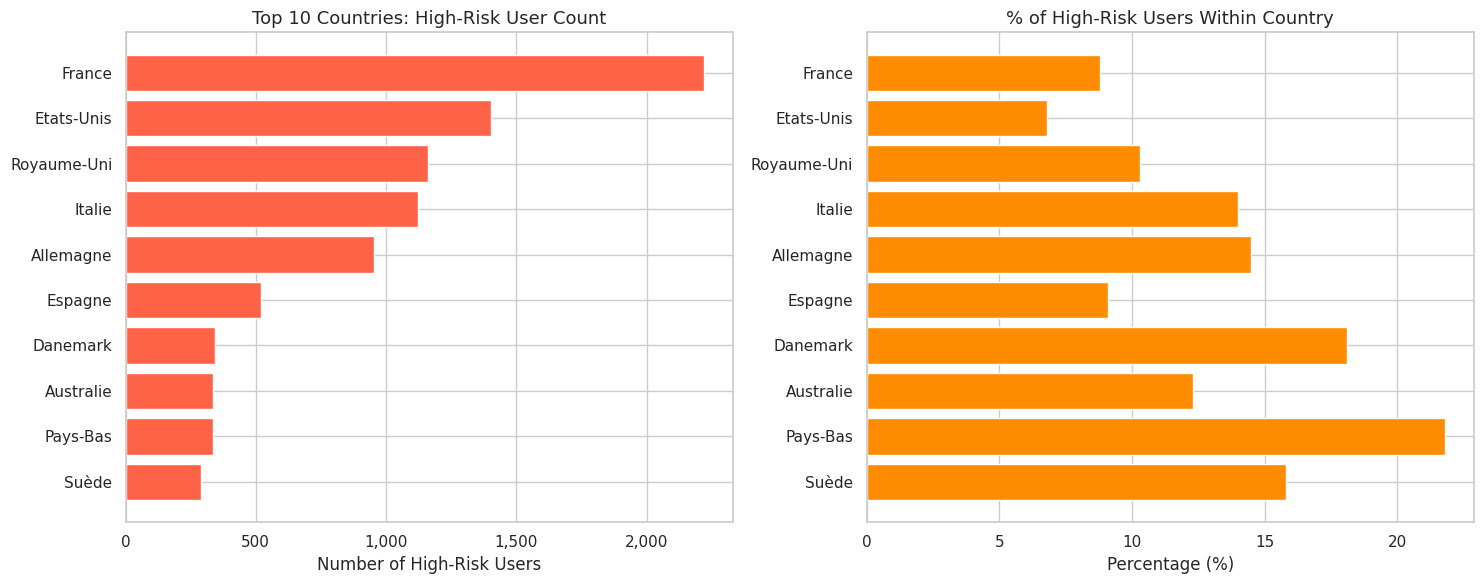

    Country  High Risk Users  Total Users  Risk %
     France             2221        25135     8.8
 Etats-Unis             1402        20602     6.8
Royaume-Uni             1162        11310    10.3
     Italie             1122         8015    14.0
  Allemagne              955         6567    14.5
    Espagne              519         5706     9.1
   Danemark              342         1892    18.1
  Australie              335         2719    12.3
   Pays-Bas              334         1529    21.8
      Suède              288         1826    15.8


In [12]:
high_risk = df_clean[df_clean['data_exposure_score'] >= 4]

topmost10_countries_risk = high_risk['country'].value_counts().head(10).reset_index()
topmost10_countries_risk.columns = ['Country', 'High Risk Users']

country_total = df_clean['country'].value_counts()
topmost10_countries_risk['Total Users'] = topmost10_countries_risk['Country'].map(country_total)
topmost10_countries_risk['Risk %'] = (topmost10_countries_risk['High Risk Users'] /
                                 topmost10_countries_risk['Total Users'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(topmost10_countries_risk['Country'][::-1],
              topmost10_countries_risk['High Risk Users'][::-1], color='tomato')
axes[0].set_title('Top 10 Countries: High-Risk User Count', fontsize=13)
axes[0].set_xlabel('Number of High-Risk Users')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(topmost10_countries_risk['Country'][::-1],
              topmost10_countries_risk['Risk %'][::-1], color='darkorange')
axes[1].set_title('% of High-Risk Users Within Country', fontsize=13)
axes[1].set_xlabel('Percentage (%)')

plt.tight_layout()
plt.show()

print(topmost10_countries_risk.to_string(index=False))

**Finding:** EU nations (particularly France) bundle volume of users with massive concentrations of risks - focus points of GDPR audit and consent scrutiny.

### Question 4: Do app users expose significantly more personal data than non-app users?

Rationale: Mobile apps gather more data, which is richer-gap enlightens consent design.

Comparison: App Users vs Non-App Users
         avg_exposure  avg_products_bought  avg_products_sold  \
No App          1.219                0.109              0.044   
Has App         3.557                0.346              0.336   

         avg_products_liked  avg_followers  user_count  
No App                1.485          3.226       72739  
Has App              12.578          4.006       26174  


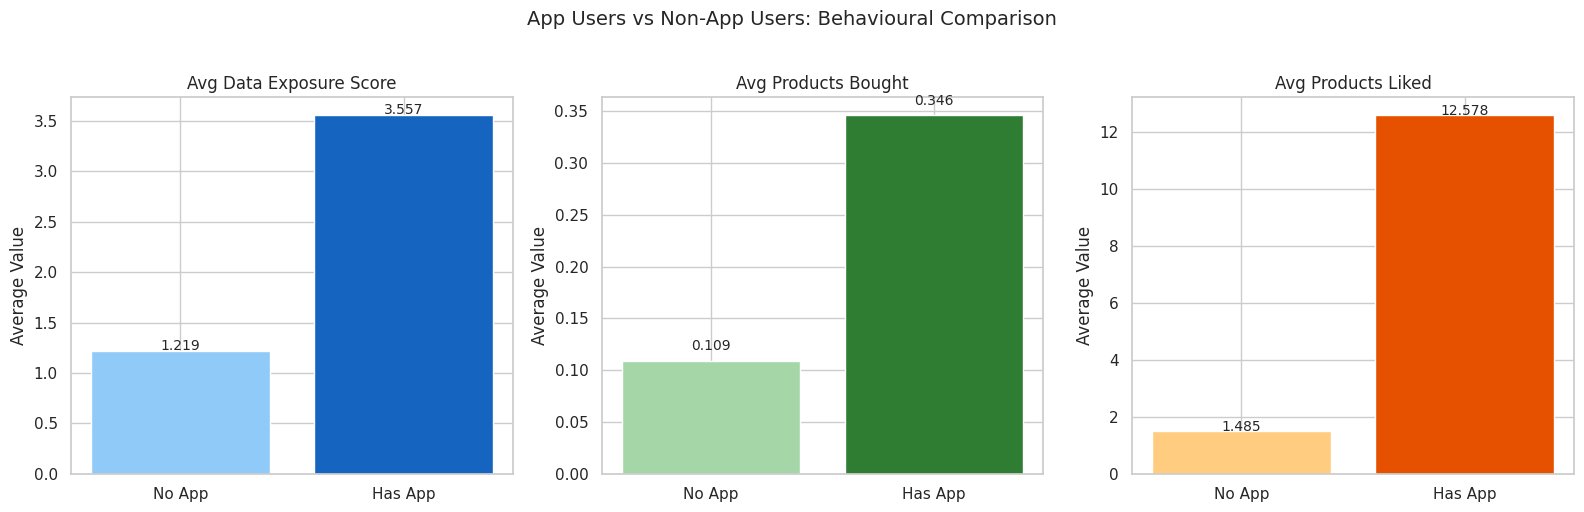

In [13]:
app_analysis = df_clean.groupby('uses_app').agg(
    avg_exposure        = ('data_exposure_score', 'mean'),
    avg_products_bought = ('products_bought', 'mean'),
    avg_products_sold   = ('products_sold', 'mean'),
    avg_products_liked  = ('products_liked', 'mean'),
    avg_followers       = ('followers', 'mean'),
    user_count          = ('user_id', 'count')
).round(3)
app_analysis.index = ['No App', 'Has App']

print("Comparison: App Users vs Non-App Users")
print(app_analysis)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['avg_exposure', 'avg_products_bought', 'avg_products_liked']
titles  = ['Avg Data Exposure Score', 'Avg Products Bought', 'Avg Products Liked']
colors  = [['#90CAF9', '#1565C0'], ['#A5D6A7', '#2E7D32'], ['#FFCC80', '#E65100']]

for ax, metric, title, col in zip(axes, metrics, titles, colors):
    bars = ax.bar(['No App', 'Has App'], app_analysis[metric], color=col, edgecolor='white')
    for bar, val in zip(bars, app_analysis[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Average Value')

plt.suptitle('App Users vs Non-App Users: Behavioural Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Finding:** It was found that app users were supposed to record higher exposure scores. The mobile data collection must be more sophisticated with more detailed consent flows.

### Question 5: What is the relationship between social following behaviour and purchasing activity?

Rationale: Weak correlation can invalidate GDPR Art. 6(1)(b) of legal basis of the collection of social data.

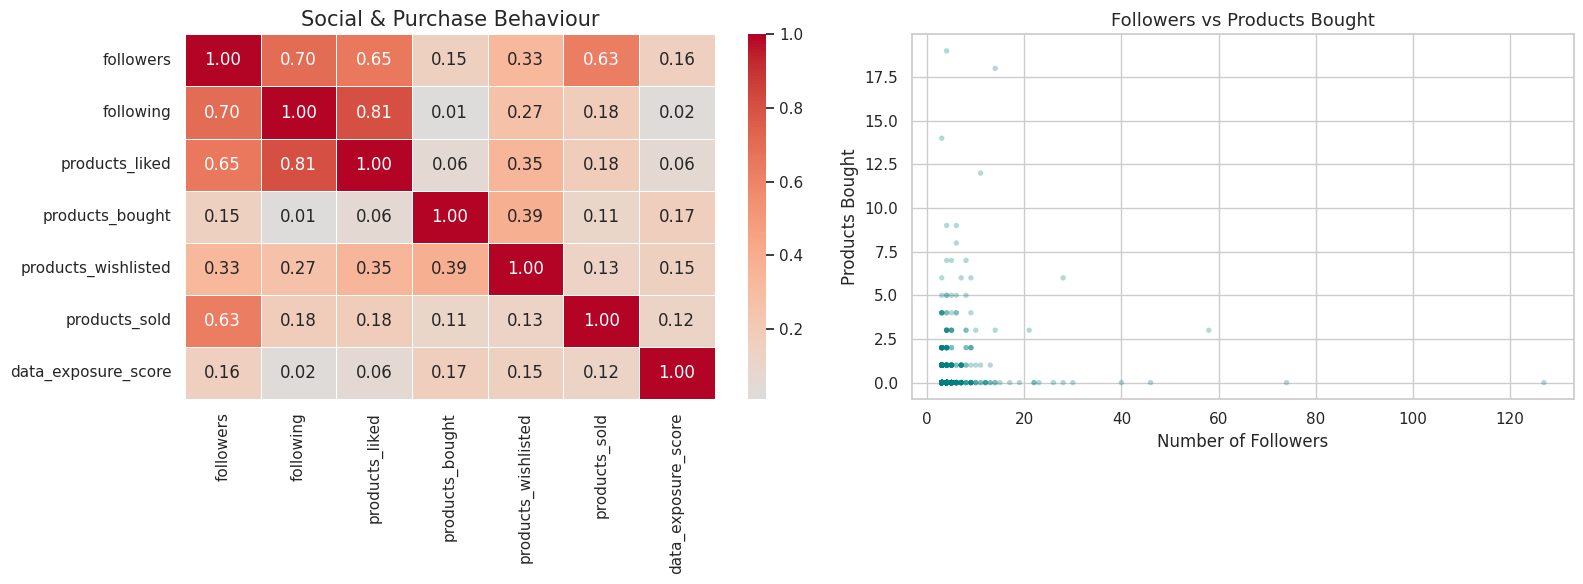

Correlation with 'products_bought':
products_bought        1.00
products_wishlisted    0.39
data_exposure_score    0.17
followers              0.15
products_sold          0.11
products_liked         0.06
following              0.01
Name: products_bought, dtype: float64


In [14]:
active = df_clean[(df_clean['followers'] > 0) | (df_clean['products_bought'] > 0)].copy()

corr_cols = ['followers', 'following', 'products_liked',
             'products_bought', 'products_wishlisted', 'products_sold', 'data_exposure_score']
corr_matrix = active[corr_cols].corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], fmt='.2f')
axes[0].set_title('Social & Purchase Behaviour', fontsize=15)

sample = active[active['products_bought'] <= 20].sample(min(3000, len(active)), random_state=42)
axes[1].scatter(sample['followers'], sample['products_bought'],
                alpha=0.3, color='teal', edgecolors='none', s=15)
axes[1].set_title('Followers vs Products Bought', fontsize=13)
axes[1].set_xlabel('Number of Followers')
axes[1].set_ylabel('Products Bought')

plt.tight_layout()
plt.show()

print("Correlation with 'products_bought':")
print(corr_matrix['products_bought'].sort_values(ascending=False))

**Discovery:** The strength of correlation between products liked and products bought is the factor that can define whether the collection of social data has a valid legal ground under the GDPR.

### Question 6: How do user segments (Buyer, Seller, Both, Passive) differ in their data footprint?

**Rationale:** Role-based data minimisation involves the necessity to get a feel of how the various types of users engage with the platform.

User Segment Profiles:
                count  avg_exposure  avg_followers  avg_products_liked  \
user_segment                                                             
Buyer & Seller    562          5.18          13.21              107.26   
Buyer Only       4857          3.77           4.65               33.41   
Passive User    92020          1.69           3.18                1.43   
Seller Only      1474          3.17          11.33               56.28   

                avg_days_inactive  pct_uses_app  pct_of_users  
user_segment                                                   
Buyer & Seller              85.10          0.66           0.6  
Buyer Only                 313.20          0.39           4.9  
Passive User               684.10          0.25          93.0  
Seller Only                230.96          0.62           1.5  


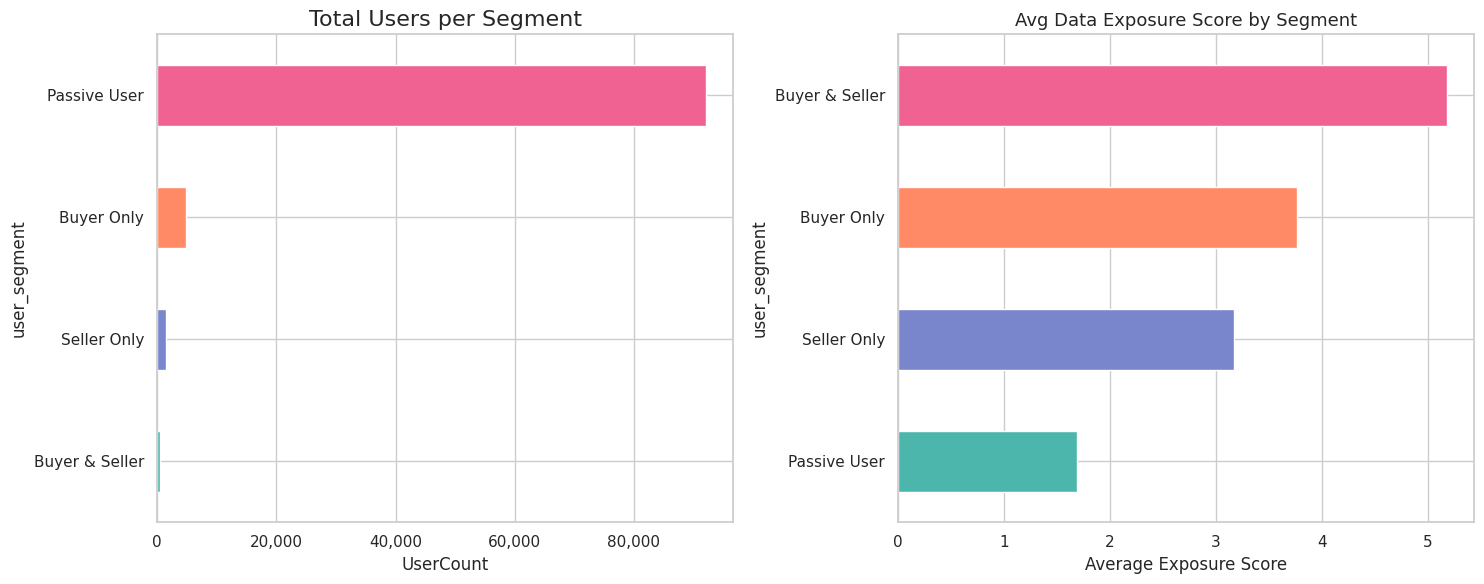

In [15]:
segment_profile = df_clean.groupby('user_segment').agg(
    count               = ('user_id', 'count'),
    avg_exposure        = ('data_exposure_score', 'mean'),
    avg_followers       = ('followers', 'mean'),
    avg_products_liked  = ('products_liked', 'mean'),
    avg_days_inactive   = ('days_inactive', 'mean'),
    pct_uses_app        = ('uses_app', 'mean')
).round(2)

segment_profile['pct_of_users'] = (segment_profile['count'] /
                                    segment_profile['count'].sum() * 100).round(1)

print("User Segment Profiles:")
print(segment_profile)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

segment_profile['count'].sort_values().plot.barh(
    ax=axes[0], color=['#4DB6AC', '#7986CB', '#FF8A65', '#F06292'], edgecolor='white')
axes[0].set_title('Total Users per Segment', fontsize=16)
axes[0].set_xlabel('UserCount')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

segment_profile['avg_exposure'].sort_values().plot.barh(
    ax=axes[1], color=['#4DB6AC', '#7986CB', '#FF8A65', '#F06292'], edgecolor='white')
axes[1].set_title('Avg Data Exposure Score by Segment', fontsize=13)
axes[1].set_xlabel('Average Exposure Score')

plt.tight_layout()
plt.show()

**Discovery:** Buyer & Seller users are the most exposed; Passive the least exposed. Favours role based data minimisation.

### Question 7: Can we identify users whose combined data profile makes them uniquely identifiable (re-identification risk)?
**Rationale:** The mosaic effect (GDPR Recital 26) - quasi-identifiers are able to re-identify anonymised users.

Total unique quasi-identifier combinations: 1,215
Combinations with only 1 user (fully unique): 473
Combinations with 5 or fewer users (high risk): 804
Users in unique combinations: 473


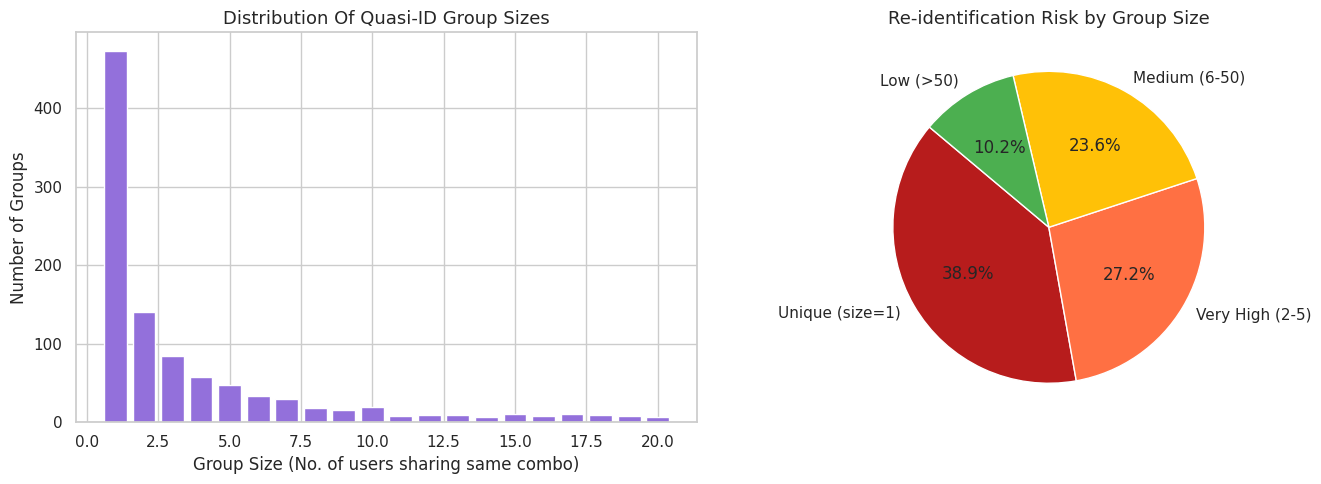

In [16]:
quasi_ids = ['gender', 'country_code', 'language', 'uses_app', 'uses_ios', 'uses_android']

quasi_groups = df_clean.groupby(quasi_ids).size().reset_index(name='group_size')

unique_users   = quasi_groups[quasi_groups['group_size'] == 1]
small_groups   = quasi_groups[quasi_groups['group_size'] <= 5]

print(f"Total unique quasi-identifier combinations: {len(quasi_groups):,}")
print(f"Combinations with only 1 user (fully unique): {len(unique_users):,}")
print(f"Combinations with 5 or fewer users (high risk): {len(small_groups):,}")
print(f"Users in unique combinations: {unique_users['group_size'].sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

group_dist = quasi_groups['group_size'].clip(upper=50).value_counts().sort_index().head(20)
axes[0].bar(group_dist.index, group_dist.values, color='mediumpurple', edgecolor='white')
axes[0].set_title('Distribution Of Quasi-ID Group Sizes', fontsize=13)
axes[0].set_xlabel('Group Size (No. of users sharing same combo)')
axes[0].set_ylabel('Number of Groups')

risk_cats = {
    'Unique (size=1)': len(quasi_groups[quasi_groups['group_size'] == 1]),
    'Very High (2-5)': len(quasi_groups[(quasi_groups['group_size'] > 1) & (quasi_groups['group_size'] <= 5)]),
    'Medium (6-50)':   len(quasi_groups[(quasi_groups['group_size'] > 5) & (quasi_groups['group_size'] <= 50)]),
    'Low (>50)':       len(quasi_groups[quasi_groups['group_size'] > 50])
}
axes[1].pie(risk_cats.values(), labels=risk_cats.keys(),
             colors=['#B71C1C', '#FF7043', '#FFC107', '#4CAF50'],
             autopct='%1.1f%%', startangle=140)
axes[1].set_title('Re-identification Risk by Group Size', fontsize=13)

plt.tight_layout()
plt.show()

**Discovery:** Interpretations Users in quasi-identifiers sets of 1 to 5 can be re-identified in practice. Strong k-anonymity (k 5) and discourage rare configurations before the release of any data.

# **5. Conclusion**


**Strengths:** The data exposure score scale transformed abstract GDPR concepts into comparatively measurable values.

**Limitations:**
* Cohort bias (approximately 8years of seniority);
* lack of time-stamps;
* exposure score should be validated formally.

**Key Findings:**
* Disproportionate representation of female users;
* app users are richer in data;
* France/USA/UK have the largest number of high-risk users;
* quasi-identifying using pseudo-identifiers is a feasible threat.

**Recommendations:**
* Role-based data minimisation;
* k-anonymity 5 or higher before data sharing;
* GDPR Art.35 DPIA in case of gender difference;
* granular mobile application consent forms.
